# Exploratory Data Analysis — Framingham Heart Study

This notebook explores feature distributions, missing values, class balance, and predictor relationships before any preprocessing.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 20)

## 2. Load Dataset

In [3]:
df = pd.read_csv('framingham_heart_study.csv')
print('Shape:', df.shape)
df.head()

Shape: (4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 3. Basic Overview

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.43,0.50,0.00,0.00,0.0,1.00,1.0
age,4240.0,49.58,8.57,32.00,42.00,49.0,56.00,70.0
education,4135.0,1.98,1.02,1.00,1.00,2.0,3.00,4.0
currentSmoker,4240.0,0.49,0.50,0.00,0.00,0.0,1.00,1.0
cigsPerDay,4211.0,9.01,11.92,0.00,0.00,0.0,20.00,70.0
BPMeds,4187.0,0.03,0.17,0.00,0.00,0.0,0.00,1.0
prevalentStroke,4240.0,0.01,0.08,0.00,0.00,0.0,0.00,1.0
prevalentHyp,4240.0,0.31,0.46,0.00,0.00,0.0,1.00,1.0
diabetes,4240.0,0.03,0.16,0.00,0.00,0.0,0.00,1.0
totChol,4190.0,236.70,44.59,107.00,206.00,234.0,263.00,696.0


## 4. Missing Value Analysis

In [6]:
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Count': missing, 'Pct %': pct})
miss_df = miss_df[miss_df['Count'] > 0].sort_values('Pct %', ascending=False)
print(miss_df)

            Count  Pct %
glucose       388   9.15
education     105   2.48
BPMeds         53   1.25
totChol        50   1.18
cigsPerDay     29   0.68
BMI            19   0.45
heartRate       1   0.02


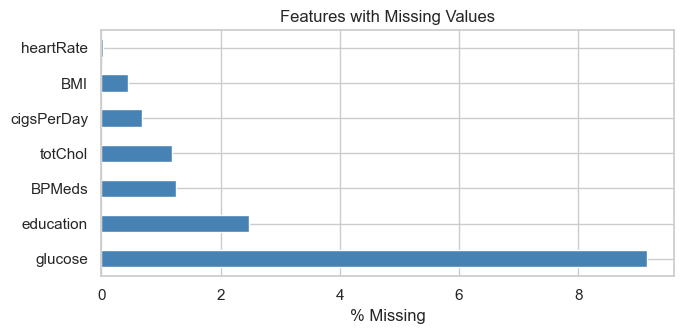

In [7]:
plt.figure(figsize=(7, 3.5))
miss_df['Pct %'].plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel('% Missing')
plt.title('Features with Missing Values')
plt.tight_layout()
plt.show()

## 5. Target Variable Distribution

TenYearCHD
0    3596
1     644
Name: count, dtype: int64

Class imbalance: 15.2% positive cases


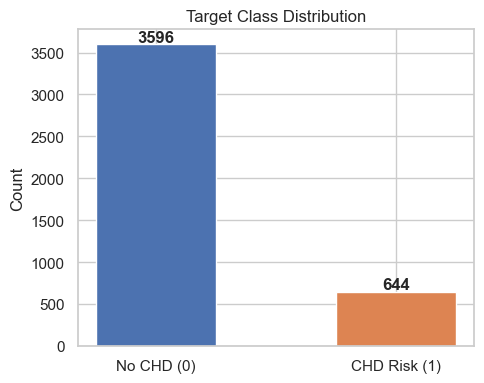

In [8]:
counts = df['TenYearCHD'].value_counts().sort_index()
print(counts)
print(f'\nClass imbalance: {counts[1]/len(df)*100:.1f}% positive cases')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No CHD (0)', 'CHD Risk (1)'], counts.values,
       color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
ax.set_ylabel('Count')
ax.set_title('Target Class Distribution')
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Univariate Distributions

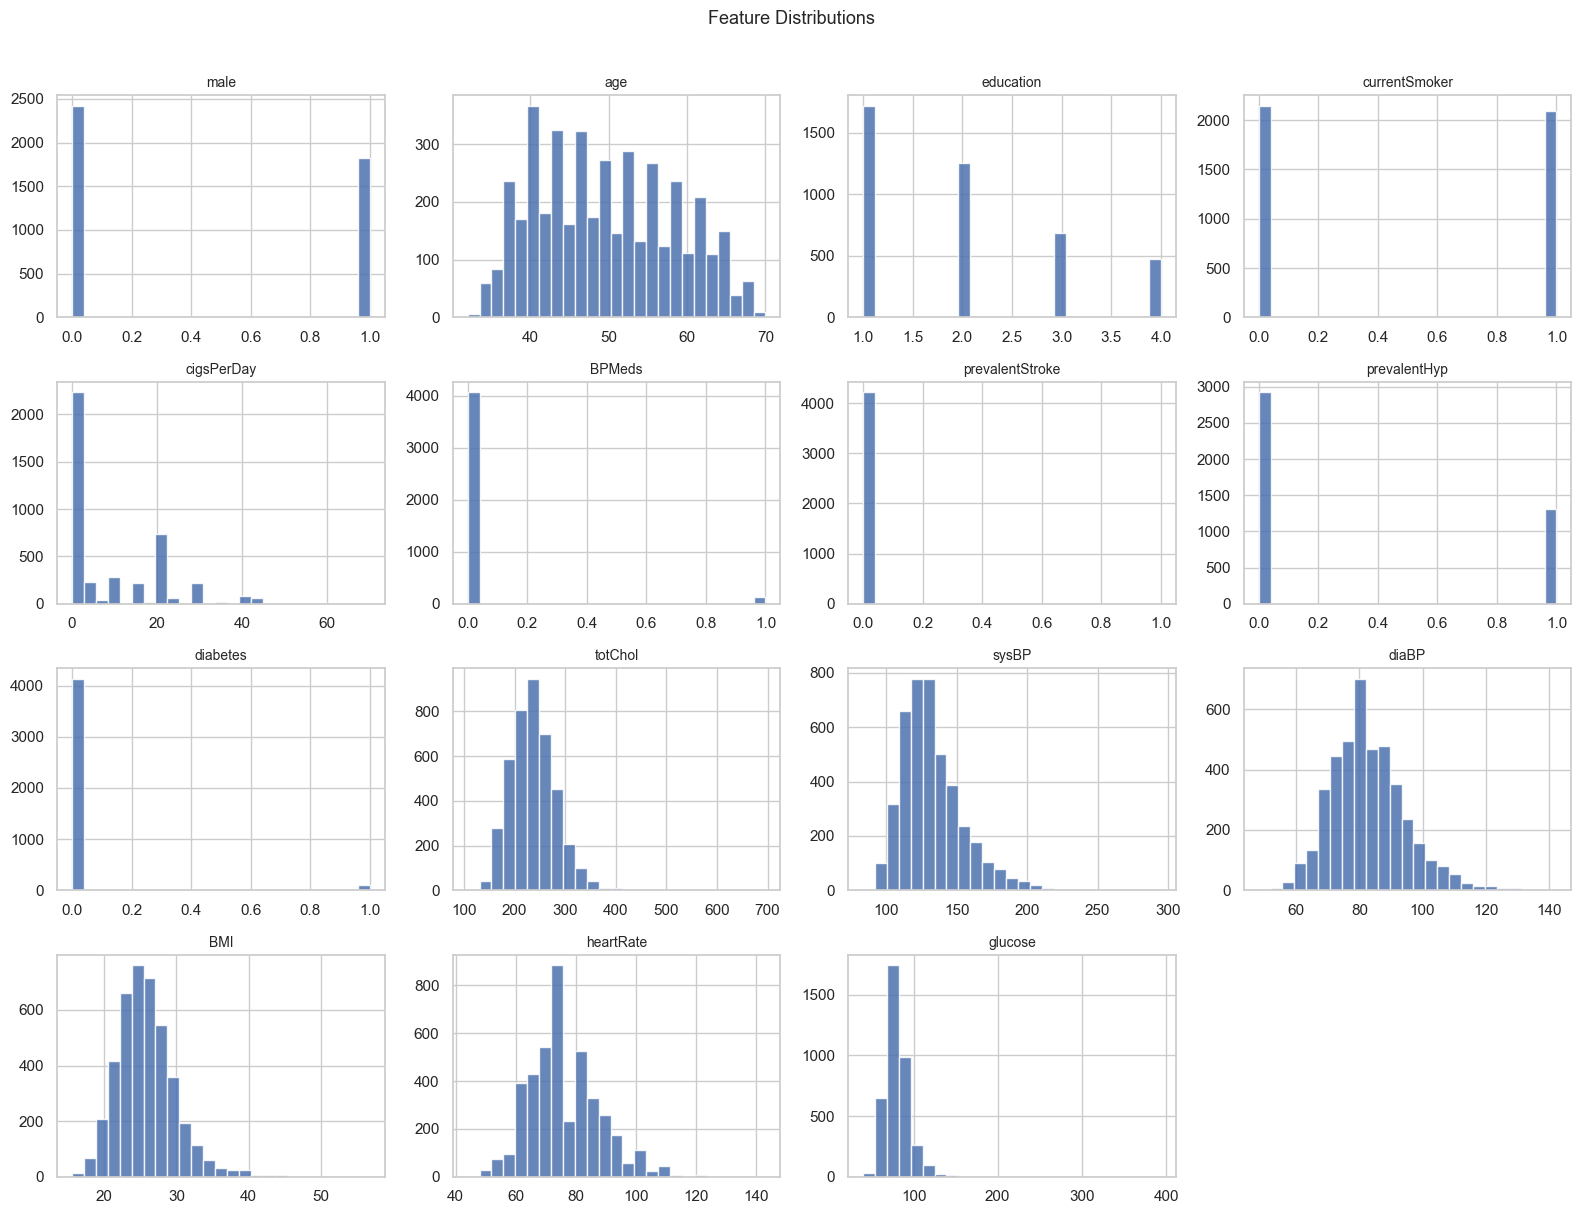

In [9]:
num_cols = [c for c in df.select_dtypes(include='number').columns if c != 'TenYearCHD']
ncols, nrows = 4, -(-len(num_cols) // 4)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=25, color='#4C72B0', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 7. Bivariate Analysis — Features vs Target

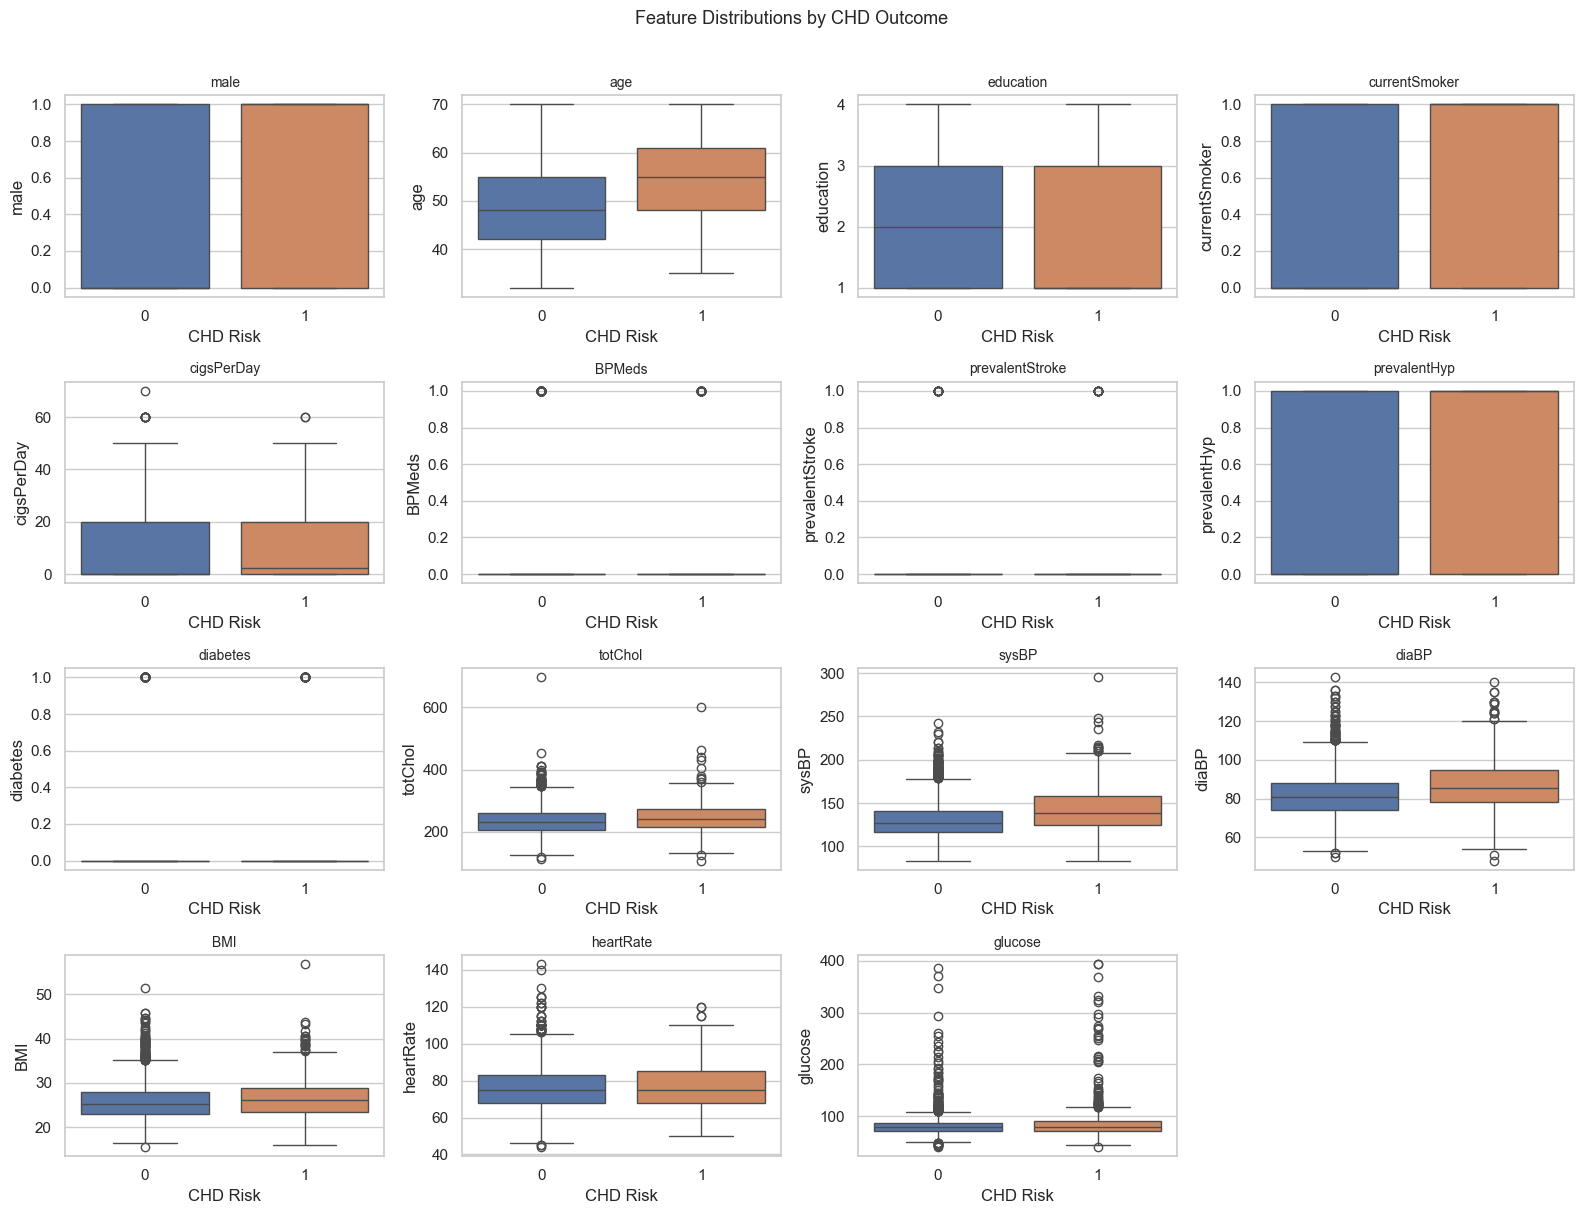

In [11]:
nrows = -(-len(num_cols) // 4)
fig, axes = plt.subplots(nrows, 4, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='TenYearCHD', y=col, data=df, ax=axes[i],
                hue='TenYearCHD', palette={0: '#4C72B0', 1: '#DD8452'},
                legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('CHD Risk')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by CHD Outcome', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 8. Correlation Heatmap

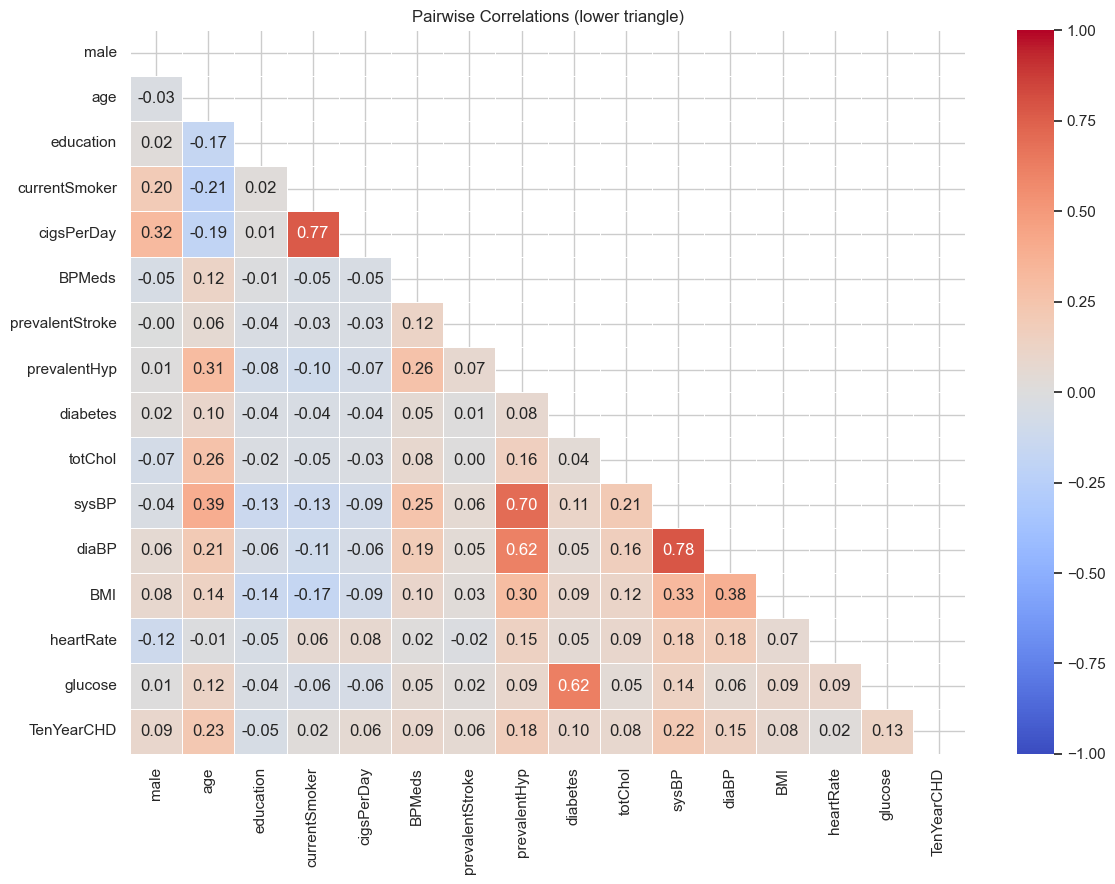

In [12]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, vmin=-1, vmax=1)
plt.title('Pairwise Correlations (lower triangle)')
plt.tight_layout()
plt.show()

In [13]:
target_corr = corr['TenYearCHD'].drop('TenYearCHD').abs().sort_values(ascending=False)
print('Absolute correlation with TenYearCHD:')
print(target_corr.round(3))

Absolute correlation with TenYearCHD:
age                0.225
sysBP              0.216
prevalentHyp       0.177
diaBP              0.145
glucose            0.126
diabetes           0.097
male               0.088
BPMeds             0.088
totChol            0.082
BMI                0.075
prevalentStroke    0.062
cigsPerDay         0.058
education          0.054
heartRate          0.023
currentSmoker      0.019
Name: TenYearCHD, dtype: float64


## 9. EDA Summary

| Finding | Detail |
|---|---|
| Rows / Columns | 4,240 × 16 |
| Missing values | `glucose` ~9%, `education` ~2.5%, others < 2% |
| Class imbalance | ~85% negative / ~15% positive |
| Strongest predictors | `age`, `sysBP`, `prevalentHyp`, `diaBP`, `glucose` |
| Weak predictors | `heartRate`, `currentSmoker`, `education` |
| Evaluation plan | AUC-ROC and F1-score as primary metrics |